## Alfvén wave collision (3D)

The natural variables of RMHD are the **Elsasser fields** $z^\pm = \phi \pm \psi$ (stream
function $\pm$ flux function). In them the equations take the schematic form

$$\partial_t z^\pm \mp v_A \partial_z z^\pm = -\tfrac{1}{2}\left(\{z^+, z^-\}\ \text{cross terms}\right) + \text{dissipation},$$

i.e. each Elsasser field is advected along the guide field at the Alfvén speed
($v_A = 1$ in code units; in this code's sign convention $z^+ = f(x,y,z+t)$ propagates
toward $-z$ and $z^- = g(x,y,z-t)$ toward $+z$, see `physics/rmhd.py::LinearTerm`), and the
**nonlinearity involves only the cross terms** $\{z^\mp, z^\pm\}$: a $z^+$ perturbation is
sheared only by $z^-$, and vice versa. Two consequences:

- A single Elsasser wave of *arbitrary* amplitude is an **exact nonlinear solution** — it
  just propagates. `AW_advection.ipynb` uses exactly this to verify the linear parallel
  dynamics; this notebook is its nonlinear companion.
- Nonlinear energy transfer happens **only while counter-propagating wave packets overlap**.
  This is Kraichnan's (1965) picture of MHD turbulence: a sea of Alfvén wave packets
  streaming up and down the mean field, cascading energy to small perpendicular scales
  through successive collisions.

The minimal such interaction — one $z^+$ wave colliding with one cross-polarized $z^-$
wave — was worked out analytically and gyrokinetically by Howes & Nielson (2013) and
Nielson, Howes & Dorland (2013). Their key result: the first nonlinear product of primaries
at $(k_x,k_y,k_z) = (1,0,1)$ and $(0,1,-1)$ is the beat mode at $(1,1,0)$ — a **purely
magnetic mode with $k_\parallel = 0$**. It does not propagate; it sits and shears the
primary waves, transferring their energy to higher $k_\perp$ and seeding the perpendicular
cascade. We reproduce that here in RMHD:

- **Collision run**: $z^+ = A\cos(x+z)$, $z^- = A\cos(y-z)$, $A = 1$ in a $(2\pi)^3$ box —
  watch the $(1,1,0)$ secondary appear in $\psi$ (magnetic) but not $\phi$ (velocity), and
  the perpendicular spectrum fill in.
- **Control run**: the same $z^+$ wave alone ($z^- = 0$) — no interaction, no cascade,
  energy conserved.


In [1]:
#imports
import shutil
import jax.numpy as jnp
import jax.numpy.fft as ft
import numpy as np
import matplotlib.pyplot as plt

import taranis as jr
import taranis.snapshot_io as sn
import taranis.diagnostics as diag


jax is using 64bit precision.


In [2]:
#grid + physical parameters
nx = 64
ny = 64
nz = 32
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi

t_snap = 1.0     # ~1 snapshot per unit time (simulate can overshoot by up to one step)
t_end = 25.0     # several Alfven crossing times (tau_A = Lz/v_A = 2*pi)
nsnap = 100
cfl_safety = 0.5
spatial_dimensions = 3

#very weak hyperdissipation: strong enough to absorb what the cascade delivers to the grid
#scale, weak enough that the primary waves are essentially undamped over the whole run
visc = 1e-8
res = 1e-8
hyper = 3

A = 1.0   #wave amplitude: chi = k_perp A / (k_par v_A) ~ 1, moderately strong collision

snap_path_collision = "data/alfven-wave-collision-3D/collision/"
snap_path_single = "data/alfven-wave-collision-3D/single-wave/"

params = jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly, nz=nz, Lz=Lz,
                        eqpars={'diss': (visc, res), 'hyper': hyper},
                        cfl_safety=cfl_safety, dims=spatial_dimensions)
kgrid = jr.setup_kgrids(params)

#fresh start: simulate_scan APPENDS to whatever snapshots already exist in a directory,
#which would scramble the snapshot-index -> time mapping the post-processing below relies on
for p in (snap_path_collision, snap_path_single):
    shutil.rmtree(p, ignore_errors=True)

params.save(snap_path_collision)   #records params.json (see postprocessing.ipynb)
params.save(snap_path_single)
mngr_collision = jr.snapshot_manager_setup(params, snap_path=snap_path_collision, nsnap=nsnap)
mngr_single = jr.snapshot_manager_setup(params, snap_path=snap_path_single, nsnap=nsnap)


### Initial conditions

`jr.initialize` calls the init function with broadcastable real-space coordinate arrays —
`x` is `(1, nx, 1)`, `y` is `(1, 1, ny)`, `z` is `(nz, 1, 1)` (see `run.py::initialize`) —
and expects the stacked `(phi, psi)` fields of shape `(2, nz, nx, ny)` back; it does the
forward FFT and applies the dealias mask itself.

The two waves are **cross-polarized**: $z^+$ varies with $x$ ($\mathbf{k}_\perp = \hat{x}$),
$z^-$ with $y$ ($\mathbf{k}_\perp = \hat{y}$). The nonlinearity is the Poisson bracket
$\{z^+, z^-\} = \hat{z}\cdot(\nabla z^+ \times \nabla z^-)$, so perpendicular wavevectors
at right angles maximize the interaction — two waves polarized along the *same*
perpendicular direction would have $\{z^+,z^-\} = 0$ and pass through each other exactly.


In [3]:
def collision_init(x, y, z):
    # x, y, z arrive broadcastable ((1,nx,1), (1,1,ny), (nz,1,1)); return (2, nz, nx, ny)
    zp = A * jnp.cos(x + z)   # z+ : propagates toward -z
    zm = A * jnp.cos(y - z)   # z- : propagates toward +z
    phi = 0.5 * (zp + zm)     # phi = (z+ + z-)/2; combining zp and zm broadcasts to full shape
    psi = 0.5 * (zp - zm)     # psi = (z+ - z-)/2
    return jnp.stack([phi, psi])

def single_wave_init(x, y, z):
    # same z+ wave, but z- = 0  =>  phi = psi = z+/2. This field only spans (z, x), so
    # broadcast to the full (nz, nx, ny) shape explicitly.
    shape = jnp.broadcast_shapes(x.shape, y.shape, z.shape)
    half_zp = jnp.broadcast_to(0.5 * A * jnp.cos(x + z), shape)
    return jnp.stack([half_zp, half_zp])


### Run the collision

Note **buffer donation**: the state passed to `jr.simulate_scan` is consumed
(`donate_argnums=(0,)` — touching it afterwards raises "Array has been deleted"), so read
any initial diagnostics *before* the call and continue from the returned state.


In [4]:
#this notebook is single-process; for larger 3D runs put the same setup in a script and
#launch it under MPI (z-domain decomposition; needs `pip install -e ".[mpi]"` and nz % nranks == 0):
#   mpirun -n 4 python alfven_wave_collision.py

state = jr.initialize(collision_init, params)
Ek0, Em0 = diag.energy(state, kgrid, params)
print(f"initial energy: E_kin={float(Ek0):.6f}  E_mag={float(Em0):.6f}  total={float(Ek0+Em0):.6f}")

nblock = jr.estimate_good_nblock(state, kgrid, params, t_snap, t_end, nblock_min=10)
print("nblock estimate: " + str(nblock))

end_state = jr.simulate_scan(state, kgrid, params, nblock, t_snap=t_snap, t_end=t_end,
                              mngr=mngr_collision, save=True)


initial energy: E_kin=0.125000  E_mag=0.125000  total=0.250000
nblock estimate: 20
Saving initial state as snapshot 0 at t = 0.0
0.9806480484345199
1.9098744508844077
Saving snapshot as snapshot 1 at t = 1.9098744508844077
2.801385223382518
3.6702903794079953
Saving snapshot as snapshot 2 at t = 3.6702903794079953
4.571785032603755
5.414690859545707
Saving snapshot as snapshot 3 at t = 5.414690859545707
6.214257532074482
7.006308962417989
Saving snapshot as snapshot 4 at t = 7.006308962417989
7.808660052630406
8.546491502425765
Saving snapshot as snapshot 5 at t = 8.546491502425765
9.265442164636035
9.979027671848941
Saving snapshot as snapshot 6 at t = 9.979027671848941
10.698606059484739
11.356498657736823
Saving snapshot as snapshot 7 at t = 11.356498657736823
11.995597845100324
12.63700539273149
Saving snapshot as snapshot 8 at t = 12.63700539273149
13.277844136085053
13.89908498459872
Saving snapshot as snapshot 9 at t = 13.89908498459872
14.472059245951979
15.043263259226833
Savi

### Run the control (single wave, $z^- = 0$)

Same resolution, dissipation, duration and (statistically) timestep — only the $z^-$ wave
is removed. If the Elsasser structure of the nonlinearity is respected by the solver, this
run should show *no* nonlinear activity at all: the wave is an exact nonlinear solution.


In [5]:
state_single = jr.initialize(single_wave_init, params)
end_state_single = jr.simulate_scan(state_single, kgrid, params, nblock, t_snap=t_snap,
                                     t_end=t_end, mngr=mngr_single, save=True)


Saving initial state as snapshot 0 at t = 0.0
0.9823466571409408
1.9647071722120466
Saving snapshot as snapshot 1 at t = 1.9647071722120466
2.947081524431772
3.92946972798924
Saving snapshot as snapshot 2 at t = 3.92946972798924
4.911871820438758
5.89428786283537
Saving snapshot as snapshot 3 at t = 5.89428786283537
6.876717939942624
7.859162160516734
Saving snapshot as snapshot 4 at t = 7.859162160516734
8.84162065767139
9.824093589328152
Saving snapshot as snapshot 5 at t = 9.824093589328152
10.806581138757753
11.789083515218126
Saving snapshot as snapshot 6 at t = 11.789083515218126
12.771600954695863
13.754133720758247
Saving snapshot as snapshot 7 at t = 13.754133720758247
14.73668210552417
15.719246430762942
Saving snapshot as snapshot 8 at t = 15.719246430762942
16.701827049131268
17.684424345559865
Saving snapshot as snapshot 9 at t = 17.684424345559865
18.66703873880247
19.649670683161816
Saving snapshot as snapshot 10 at t = 19.649670683161816
20.6323206704087
21.614989231912

### Secondary-mode growth: the punchline

The fields are stored real-space in $z$ and rfft2 in $(x,y)$, so the **$z$-average of
`fields` extracts the $k_\parallel = 0$ component**, and index `[kx=1, ky=1]` of that picks
out the $(1,1,0)$ beat mode. Division by `nx*ny` converts the unnormalized FFT coefficient
to a real-space mode amplitude (`grids.fft` is unnormalized, so an $O(1)$ field has
$O(n_x n_y)$ coefficients).

Howes & Nielson's prediction: in the collision run this mode appears in $\psi$ (magnetic)
at $O(A^2)$ within an Alfvén time, while its $\phi$ (velocity) counterpart stays at
round-off level — the secondary is a **purely magnetic, non-propagating shear mode**. In
the control run both stay at round-off.


In [6]:
def timeseries(snap_path):
    ts, amp_phi, amp_psi, E_tot = [], [], [], []
    for isnap in sorted(sn.get_saved_steps(snap_path)):
        snap = sn.load_snapshot(isnap, snap_path, params)
        phik, psik = snap.fields[0], snap.fields[1]
        # z-mean of the (real-space-in-z) fields = k_par = 0 component; [1,1] = (kx=1, ky=1)
        amp_phi.append(float(jnp.abs(jnp.mean(phik[:, 1, 1]))) / (nx * ny))
        amp_psi.append(float(jnp.abs(jnp.mean(psik[:, 1, 1]))) / (nx * ny))
        Ek, Em = diag.energy(snap, kgrid, params)
        ts.append(float(snap.t))
        E_tot.append(float(Ek + Em))
    return (np.array(ts), np.array(amp_phi), np.array(amp_psi), np.array(E_tot))

t_c, phi11_c, psi11_c, E_c = timeseries(snap_path_collision)
t_s, phi11_s, psi11_s, E_s = timeseries(snap_path_single)

print(f"collision: |psi(1,1,kpar=0)| max = {psi11_c.max():.3e},  |phi(1,1,kpar=0)| max = {phi11_c.max():.3e}")
print(f"control:   |psi(1,1,kpar=0)| max = {psi11_s.max():.3e},  |phi(1,1,kpar=0)| max = {phi11_s.max():.3e}")


collision: |psi(1,1,kpar=0)| max = 1.073e-01,  |phi(1,1,kpar=0)| max = 4.985e-17
control:   |psi(1,1,kpar=0)| max = 0.000e+00,  |phi(1,1,kpar=0)| max = 0.000e+00


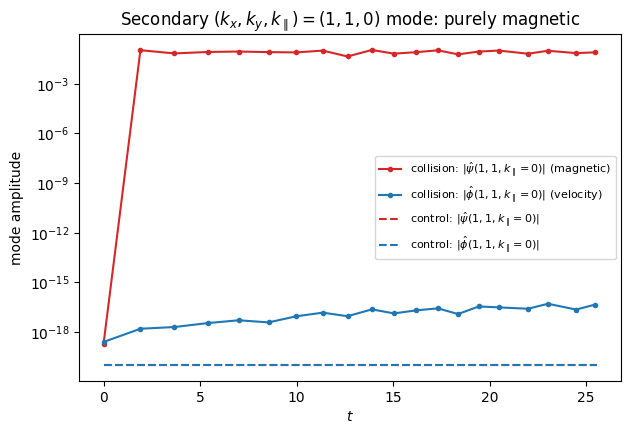

In [7]:
floor = 1e-20   #so exact zeros survive the log axis
plt.figure(figsize=(7, 4.5))
plt.semilogy(t_c, np.maximum(psi11_c, floor), 'C3-', marker='o', markersize=3,
             label=r'collision: $|\hat\psi(1,1,k_\parallel{=}0)|$ (magnetic)')
plt.semilogy(t_c, np.maximum(phi11_c, floor), 'C0-', marker='o', markersize=3,
             label=r'collision: $|\hat\phi(1,1,k_\parallel{=}0)|$ (velocity)')
plt.semilogy(t_s, np.maximum(psi11_s, floor), 'C3--',
             label=r'control: $|\hat\psi(1,1,k_\parallel{=}0)|$')
plt.semilogy(t_s, np.maximum(phi11_s, floor), 'C0--',
             label=r'control: $|\hat\phi(1,1,k_\parallel{=}0)|$')
plt.xlabel(r'$t$')
plt.ylabel('mode amplitude')
plt.title(r'Secondary $(k_x,k_y,k_\parallel)=(1,1,0)$ mode: purely magnetic')
plt.legend(fontsize=8, loc='center right')
plt.show()


The secondary $\psi$ mode jumps to $O(10^{-1})$ within a couple of time units and
oscillates as energy sloshes between the primaries and the beat mode, while the $\phi$
component sits seven orders of magnitude lower (fp32 round-off), and in the control run both
amplitudes are exactly zero. This is the RMHD version of Fig. 2 of Nielson et al. (2013).


### Perpendicular spectrum: cascade onset

`diag.perpspec` gives the $z$-averaged perpendicular energy spectrum. In the collision run
the secondary shears the primaries, whose products shear again — successive collisions
populate bins at ever higher $k_\perp$. The control run should keep all its energy in the
initial $k_\perp = 1$ bin, with the other bins at round-off.


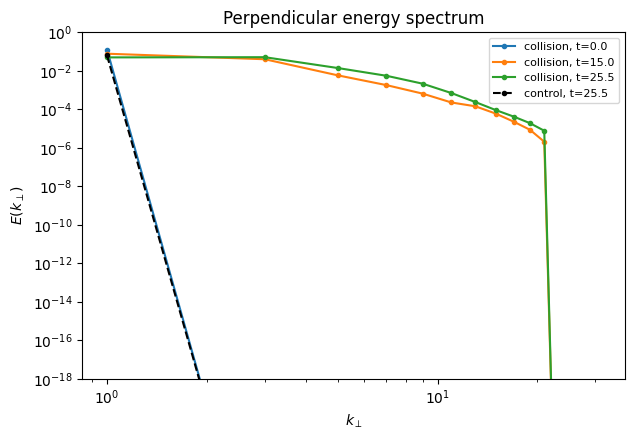

In [8]:
def spec_total(snap_path, isnap):
    snap = sn.load_snapshot(isnap, snap_path, params)
    bins, su, sb = diag.perpspec(snap, kgrid, params)
    return float(snap.t), bins, np.array(su) + np.array(sb)

steps = sorted(sn.get_saved_steps(snap_path_collision))
picks = [steps[0], steps[len(steps) // 2], steps[-1]]

plt.figure(figsize=(7, 4.5))
for i, isnap in enumerate(picks):
    t_i, bins, s_c = spec_total(snap_path_collision, isnap)
    plt.loglog(bins, np.maximum(s_c, 1e-30), f'C{i}-', marker='o', markersize=3,
               label=f'collision, t={t_i:.1f}')
t_i, bins, s_s = spec_total(snap_path_single, sorted(sn.get_saved_steps(snap_path_single))[-1])
plt.loglog(bins, np.maximum(s_s, 1e-30), 'k--', marker='.', label=f'control, t={t_i:.1f}')
plt.xlabel(r'$k_\perp$')
plt.ylabel(r'$E(k_\perp)$')
plt.title('Perpendicular energy spectrum')
plt.ylim(1e-18, 1)
plt.legend(fontsize=8)
plt.show()


### Elsasser spectra

A trick worth knowing: `perpspec` computes $\frac{1}{2}k_\perp^2|f_k|^2$ spectra of whatever
two fields sit in `state.fields`, so handing it a state whose fields are $(z^+, z^-)$
instead of $(\phi, \psi)$ — via `state._replace` (never positional `SimulationState(...)`)
— yields the Elsasser spectra directly. Here it shows the collision stays nearly balanced:
$z^+$ and $z^-$ cascade together, as they must by symmetry of this IC (each scatters the
other equally).


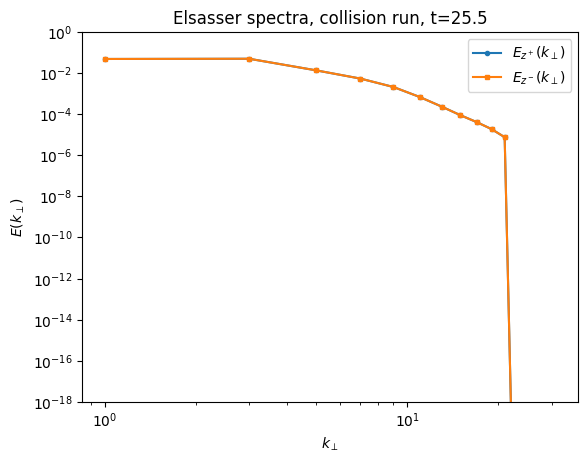

In [9]:
def elsasser_spec(snap):
    phik, psik = snap.fields[0], snap.fields[1]
    zstate = snap._replace(fields=jnp.stack([phik + psik, phik - psik]))
    return diag.perpspec(zstate, kgrid, params)   # returns (bins, E_z+, E_z-)

snap_final = sn.load_snapshot(steps[-1], snap_path_collision, params)
bins, sp, sm = elsasser_spec(snap_final)
plt.loglog(bins, np.maximum(np.array(sp), 1e-30), marker='o', markersize=3, label=r'$E_{z^+}(k_\perp)$')
plt.loglog(bins, np.maximum(np.array(sm), 1e-30), marker='s', markersize=3, label=r'$E_{z^-}(k_\perp)$')
plt.xlabel(r'$k_\perp$')
plt.ylabel(r'$E(k_\perp)$')
plt.ylim(1e-18, 1)
plt.title(f'Elsasser spectra, collision run, t={float(snap_final.t):.1f}')
plt.legend()
plt.show()


### Energy conservation

With `hyper=3` hyperdissipation at $10^{-8}$, energy should be conserved to a fraction of a
percent in the control run (the primary at $k_\perp = 1$ barely feels $k^{6}$
dissipation), and drop only slightly more in the collision run as the cascade carries
energy to dissipative scales.


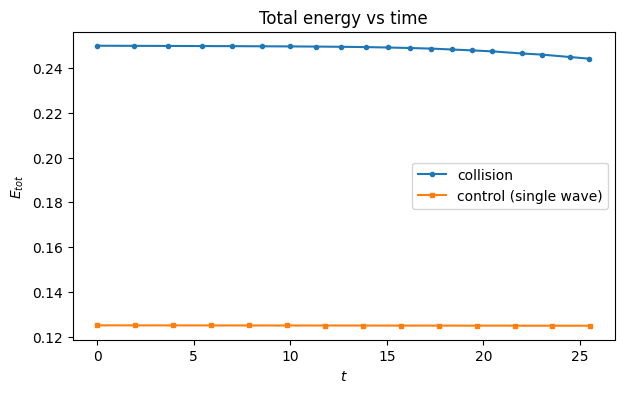

collision: E 0.250000 -> 0.244211  (-2.32%)
control:   E 0.125000 -> 0.124821  (-0.14%)


In [10]:
plt.figure(figsize=(7, 4))
plt.plot(t_c, E_c, marker='o', markersize=3, label='collision')
plt.plot(t_s, E_s, marker='s', markersize=3, label='control (single wave)')
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{tot}$')
plt.title('Total energy vs time')
plt.legend()
plt.show()

print(f"collision: E {E_c[0]:.6f} -> {E_c[-1]:.6f}  ({100*(E_c[-1]/E_c[0]-1):+.2f}%)")
print(f"control:   E {E_s[0]:.6f} -> {E_s[-1]:.6f}  ({100*(E_s[-1]/E_s[0]-1):+.2f}%)")


### Developed perpendicular structure

Real-space parallel current density $j_\parallel = -\nabla_\perp^2\psi$ in the mid-plane
$z = L_z/2$ at the final time. The collision run has developed fine current sheets from the
initially smooth $k_\perp = 1$ waves; the control run is still the unmodified single wave.


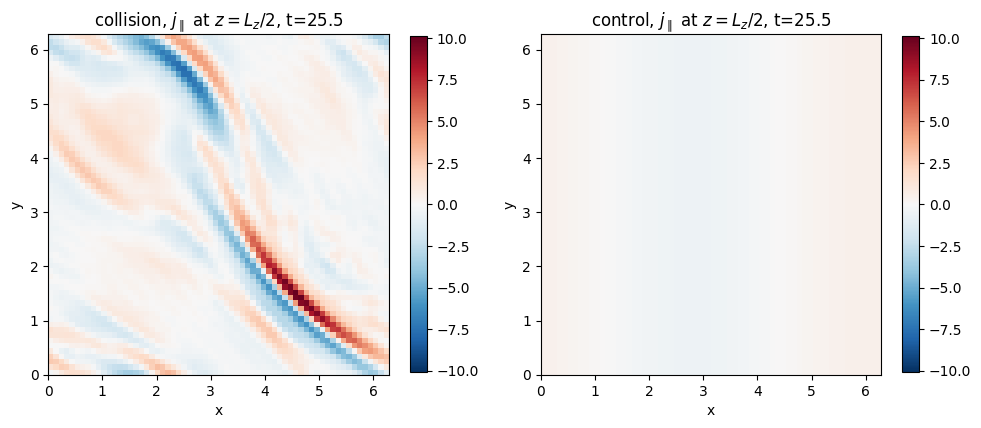

In [11]:
jz_c = ft.irfft2(-kgrid.ksq * end_state.fields[1])[nz // 2]          #(nx, ny) mid-plane slice
jz_s = ft.irfft2(-kgrid.ksq * end_state_single.fields[1])[nz // 2]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
vmax = float(jnp.max(jnp.abs(jz_c)))
for ax, jz, name, t_fin in ((axes[0], jz_c, 'collision', end_state.t),
                            (axes[1], jz_s, 'control', end_state_single.t)):
    im = ax.imshow(np.asarray(jz).T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                   extent=[0, float(Lx), 0, float(Ly)])
    ax.set_title(f'{name}, $j_\parallel$ at $z=L_z/2$, t={float(t_fin):.1f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()
